In [1]:
# PROJECT : QuGAN Handson Notebook

### 1. Import Library

In [3]:
%matplotlib inline 
import matplotlib.pyplot as plt

import numpy as np
from datasets import load_dataset

import seaborn as sns 
import os
from datetime import datetime
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from sklearn.decomposition import PCA
import time

from tqdm import tqdm

today = datetime.today().strftime('%y%m%d')

In [4]:
from function import pca_func as pf
from function import circuit_func as cf
from function import util_func as uf

In [5]:
# 시뮬레이터 설정
backend = AerSimulator()

#### Config 설정

In [6]:
config_json = uf.load_config_yaml()

learning_rate = config_json['learning_settings']['learning_rate']
train_iter = config_json['learning_settings']['train_iter']
train_on_fake = config_json['learning_settings']['train_on_fake']
train_size = config_json['learning_settings']['train_size']

tracked_d_loss = config_json['tracking']['tracked_d_loss']
tracked_g_loss = config_json['tracking']['tracked_g_loss']
tracked_loss_d_to_g = config_json['tracking']['tracked_loss_d_to_g']
tracked_loss_d_to_real = config_json['tracking']['tracked_loss_d_to_real']

corr = config_json['metrics']['corr']
wrong = config_json['metrics']['wrong']
loss_d_to_g = config_json['metrics']['loss_d_to_g']
loss_d_to_real = config_json['metrics']['loss_d_to_real']

print(f'LEARNING STATES...\nLearing Rate: {learning_rate}\nIteration: {train_iter}\nTrain Size: {train_size}')

LEARNING STATES...
Learing Rate: 0.01
Iteration: 10
Train Size: 10


### 2. Dataset 설정

In [8]:
mnist_dataset = load_dataset("ylecun/mnist")

README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

#### (1) Sample Image

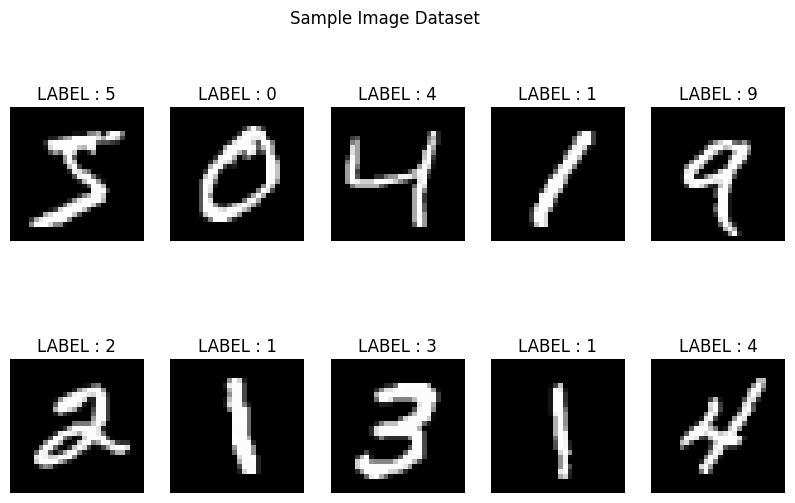

In [9]:
num_samples_to_plot = 10
grid_rows = 2
grid_cols = 5

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(10, 6))
axes = axes.flatten()

fig.suptitle(f'Sample Image Dataset')

for i in range(num_samples_to_plot):
    sample = mnist_dataset['train'][i]

    image = sample['image']
    label = sample['label']

    ax = axes[i]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'LABEL : {label}')
    ax.axis('off')

plt.show()

In [10]:
# Train dataset -> config.yaml에 train_size로 데이터 개수 조절
train_dataset = mnist_dataset['train']

# Train dataset numpy 변환
train_dataset.set_format(type='numpy', columns=['image', 'label'])
train_images = train_dataset['image'].reshape(-1, 784)
train_images = train_images/255
train_labels = train_dataset['label']

### 3. PCA 설정

In [11]:
k = 4 # 논문에서 PCA 차원 축소를 4로 설정
pca = PCA(n_components=k)
pca.fit(train_images)
pca_data = pca.transform(train_images)[:train_size]
train_labels = train_labels[:train_size]

descaling_params = list(list() for _ in range(k))

In [12]:
'''Min-Max 스케일링

모든 PCA 데이터를 양자 회로에 입력하기 적합한 [0, 1] 범위로 변환하고, 
동시에 pca_descaler 변수에 나중에 원래 값으로 복원(역변환)하기 위한 정보 (min, max)를 저장해두는, 
두 가지 역할을 동시에 수행함
'''
descaling_params, pca_data = pf.save_descaling_params(k, descaling_params, pca_data)

100%|██████████| 4/4 [00:00<00:00, 21816.93it/s]


In [13]:
descaling_params

[[np.float64(-3.407477529573872), np.float64(7.3750005721838185)],
 [np.float64(-2.8648739891232506), np.float64(5.246039546886683)],
 [np.float64(-2.715226248702941), np.float64(3.6885234551046153)],
 [np.float64(-2.043181754194076), np.float64(5.5030065473986145)]]

### 4. Data Qubitazation

차원 축소된 데이터를 큐비트에 input data로 처리하기 위해 encoding을 진행하며,
대표적인 rotation encoding (회전 인코딩)을 적용함

$$rotation =  2*arcsin(root(x))$$

In [14]:
# rotation =  2*sin^-1(root(x))
pca_data_rot = 2*np.arcsin(np.sqrt(pca_data))
target_labels= [3, 6, 9]
valid_labels = np.isin(train_labels, target_labels)

pca_data_rot = pca_data_rot[valid_labels]
pca_data     = pca_data[valid_labels]

print(f'Train 데이터 개수 : {len(pca_data_rot)}')
print(f'{k} 차원의 데이터 분산은 {sum(pca.explained_variance_ratio_).round(3)}')

Train 데이터 개수 : 2
4 차원의 데이터 분산은 0.284


### 5. QuGAN 구현

#### (1) Parameter 설정

In [15]:
# Initialization Parameter

q = 2*k + 1  # set it to dimensionality of data 2*d + 1 (Auxilary qubit)
c = 1  # Classic qubit for measurement
layer_style = 'Controlled-Dual'
tracked_kl_div = []

circ = QuantumCircuit(q, c)
circ.h(0)

train_var = cf.init_random_variables(q-1, layer_style)

#### (2) 훈련

In [17]:
print('Starting Training')
print('-'*20)

# 전체 epoch 반복 (QGAN training loop)
for epoch in tqdm(range(train_iter), total = train_iter):

    # parameter-shift rule에서 사용하는 shift 크기 (epoch에 따라 감소 → 안정화 효과)
    par_shift = 0.5*np.pi*np.sqrt(1/(epoch+1))
    
    # ------------------------------------------------------------------------------------------
    # 판별자(Discriminator) 훈련 부분입니다.
    # 각 데이터 포인트는 무작위 숫자에 대해 테스트되며, 판별자는 가짜 또는 실제를 구별하도록 훈련됩니다.
    # 이로 인해 손실 함수가 "불안정"해 보일 수 있지만, 크게 불안정하지는 않고 약간 일관성이 없을 뿐입니다.
    # ------------------------------------------------------------------------------------------
    counter = 0

    # 현재 epoch 기준 양자 회로 생성 (discriminator + generator 포함 구조)
    training_circuit = cf.training_circuit(q, c, par_shift, layer_style)

    # --------------------------
    # (1) Fake data 학습
    # --------------------------
    for _ in range(train_on_fake):
        for key, value in train_var.items():

            # 특정 큐비트 절반 이후 파라미터는 제외 (generator / discriminator 구분 목적)
            if str(q//2 + 1) in key:
                break
            
            for key_value in range(len(value)):
                forward_diff = cf.cost_function(
                    cf.get_probabilities(
                        backend, 
                        training_circuit.disc_fake_train(
                            train_var, key, key_value, diff=True, fwd_diff=True, Sample=False
                        ),
                        counts=10
                    ),
                    1 # fake label = 1 (discriminator target)
                )
                backward_diff = cf.cost_function(
                    cf.get_probabilities(
                        backend, 
                        training_circuit.disc_fake_train(
                            train_var, key, key_value, diff=True, fwd_diff=False, Sample=False
                        ),
                        counts=10
                    ),
                    1 # fake label = 1 (discriminator target)
                )
                
                # gradient approximation (parameter-shift rule)
                df = 0.5 * (forward_diff - backward_diff)
                
                # gradient clipping (기울기 조절)
                if abs(df) > 1:
                    df = df/abs(df)

                # discriminator parameter update
                train_var[key][key_value] -= df*learning_rate/10

    # --------------------------
    # (2) Real data 학습
    # --------------------------
    for index, point in enumerate(pca_data_rot):
        loss_d = [0,0]
        # 판별자 훈련:
        for key, value in train_var.items():

            # discriminator parameter만 업데이트
            if str(q//2 + 1) in key:
                break
            
            for key_value in range(len(value)):
                forward_diff = cf.cost_function(
                    cf.get_probabilities(
                        backend,
                        training_circuit.disc_real_train(
                            train_var, point, key, key_value, diff=True, fwd_diff=True
                        ),
                        counts=10
                    ),
                    0 # real label = 0
                )
                backward_diff = cf.cost_function(
                    cf.get_probabilities(
                        backend,                        
                        training_circuit.disc_real_train(
                            train_var, point, key, key_value, diff=True, fwd_diff=False
                        ),
                        counts=10
                    ),
                    0 # real label = 0
                )
                
                # gradient estimation
                df = 0.5 * (forward_diff - backward_diff)

                # discriminator update (real data 방향)
                train_var[key][key_value] -= learning_rate * df

        loss_d[0] += cf.cost_function(
            cf.get_probabilities(
                backend,
                training_circuit.disc_real_train(
                    train_var, point, key, key_value, diff=False, fwd_diff=False
                ),
                counts=10
            ),
            0
        )
        loss_d[1] += 1
    loss_d_to_real = loss_d[0]/loss_d[1]
    
    # ------------------------------------------------------------------------------------------
    # 생성자(Generator) 훈련 부분입니다.
    # 판별자는 위에서 학습한 상태를 속이는 데 중점을 둡니다.
    # 큐비트 상태가 과도하게 회전하지 않도록 너무 크게 만들지 않습니다.
    # ------------------------------------------------------------------------------------------
    loss_g = [0,0]
    for _ in range(len(pca_data_rot//10)):
        gen_params = True

        for key, value in train_var.items():
            if str(q//2 + 1) not in key and gen_params:
                continue
            else:
                gen_params = False

            for key_value in range(len(value)):
                forward_diff = cf.generator_cost_function(
                    cf.get_probabilities(
                        backend,                        
                        training_circuit.disc_fake_train(
                            train_var, key, key_value, diff=True, fwd_diff=True
                        ),
                        counts=10
                    )
                )
                backward_diff = cf.generator_cost_function(
                    cf.get_probabilities(
                        backend,
                        training_circuit.disc_fake_train(
                            train_var, key, key_value, diff=True, fwd_diff=False
                        ),
                        counts=10
                    )
                )
                df = 0.5 * (forward_diff - backward_diff)
                train_var[key][key_value] -= df * learning_rate * 2.5
        loss_g[0] += cf.generator_cost_function(
            cf.get_probabilities(
                backend,
                training_circuit.disc_fake_train(
                    train_var, key, key_value, diff=False, fwd_diff=False
                ),
                counts=10
            )
        )
        loss_g[1] += 1
    generator_loss = loss_g[0]/loss_g[1]

    tracked_g_loss.append(generator_loss)
    loss_qgan = cf.cost_function(
        cf.get_probabilities(
            backend,                        
            training_circuit.disc_fake_train(
                train_var, key, key_value, diff=False, fwd_diff=False, Sample=False
            ),
            counts=10
        ), 1
    )
    t_loss = loss_qgan + loss_d_to_real

    tracked_loss_d_to_real.append(loss_d_to_real)
    tracked_loss_d_to_g.append(loss_qgan)
    tracked_d_loss.append(t_loss)

    ############################################################
    # Plot Distribution
    ############################################################
    plot_circ, plot_data = uf.plot_kde_scatter(
        train_iter, epoch, backend, training_circuit, train_var, pca_data, target_labels, q,
        plot_frequency=5, shots= 20, num_samples= 500, dist_plot_path= './images/distribution_plot/'
    )
    
    ############################################################
    # Image generation
    ############################################################
    uf.plot_generated_images(train_iter, epoch, backend, descaling_params, pca,
                             plot_frequency=5, circ=plot_circ, n_results=q//2, 
                             generated_plot_path='./images/generated_plot/'
    )
    
    ############################################################
    # Plot Loss and kullback leibler divergence
    ############################################################
    dist_analyzer = cf.DistributionAnalyzer()
    dim_kl_div = dist_analyzer.generate_kl_divergence_hist(pca_data, plot_data)
    tracked_kl_div.append(np.mean(np.array(dim_kl_div)))

############################################################
# Save Variables
############################################################
uf.save_variables(epoch, today, train_var, 
                  tracked_kl_div, tracked_g_loss, tracked_d_loss,
                  save_path='./results/'
                 )



Starting Training
--------------------


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 plot saved....


 50%|█████     | 5/10 [00:08<00:07,  1.54s/it]

Epoch 6 plot saved....


 90%|█████████ | 9/10 [00:14<00:01,  1.57s/it]

Epoch 10 plot saved....


100%|██████████| 10/10 [00:17<00:00,  1.75s/it]

TRAINED VARAIBLES SAVED.....


<Figure size 640x480 with 0 Axes>